In [1]:
import numpy as np
import h5py
from astropy.io import fits
from astropy.visualization import LogStretch, ImageNormalize
import os
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt

In [2]:
path = "/home/aadam/scratch/SKIRT_TNG/"

In [3]:
files = []
for d in tqdm(os.listdir(path)):
    for f in glob(os.path.join(path, d, "*.fits")):
        files.append(f)

100%|██████████| 7/7 [00:00<00:00, 15.14it/s]


# Prior sampling

In [5]:
from scope.models import NCSNpp
from scope.sde import VESDE
from astropy.visualization import ImageNormalize, LogStretch
from scope.score_samplers import EulerMaruyama
from scope.definitions import DEVICE
import torch
import os, json, re
from glob import glob
import numpy as np
import matplotlib.pyplot as plt

/home/aadam/environments/scope/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_skirt_g_256_230523001306"
# checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_skirt_g_64_230523001203"
# checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_skirt_g_128_230523001212"

with open(os.path.join(checkpoint_dir, "model_hparams.json"), "r") as f:
    hyperparameters = json.load(f)
model = NCSNpp(**hyperparameters).to(DEVICE)
paths = glob(os.path.join(checkpoint_dir, "checkpoint*.pt"))
checkpoints = [int(re.findall('[0-9]+', os.path.split(path)[-1])[-1]) for path in paths]
model.eval()
for p in model.parameters(): p.requires_grad = False  # being extra careful for some reasons
model.load_state_dict(torch.load(paths[np.argmax(checkpoints)], map_location=DEVICE))
sde = VESDE(sigma_min=hyperparameters["sigma_min"], sigma_max=hyperparameters["sigma_max"], N=1000)

In [7]:
hyperparameters

{'channels': 1,
 'nf': 128,
 'ch_mult': [1, 1, 2, 2, 4, 4],
 'image_size': 256,
 'activation_type': 'swish',
 'resample_with_conv': True,
 'fir': True,
 'fir_kernel': [1, 3, 3, 1],
 'skip_rescale': True,
 'progressive': 'output_skip',
 'progressive_input': 'input_skip',
 'init_scale': 0.01,
 'fourier_scale': 16.0,
 'resblock_type': 'biggan',
 'combine_method': 'sum',
 'num_res_blocks': 2,
 'dropout': 0,
 'attention': False,
 'sigma_min': 0.0001,
 'sigma_max': 300,
 'dynamic_range': 100000.0,
 'linear_preprocessing': False}

In [8]:
sum([np.prod(p.shape) for p in model.parameters()]) / 1e6

119.88487

In [9]:
W = 8
N = 2000
pixels = 256
sigma = lambda t: sde.marginal_prob(None, t)[1]

sampler = EulerMaruyama(sde=sde, conditioned_score_fn=lambda x, t: model(x, t) / sigma(t).view(-1, 1, 1, 1), N=N)
samples = torch.randn([W, 1, pixels, pixels]).to(DEVICE)
samples = sampler.sample(samples, N, save_last_only=True)

100%|██████████| 2000/2000 [12:14<00:00,  2.72it/s]


# 64

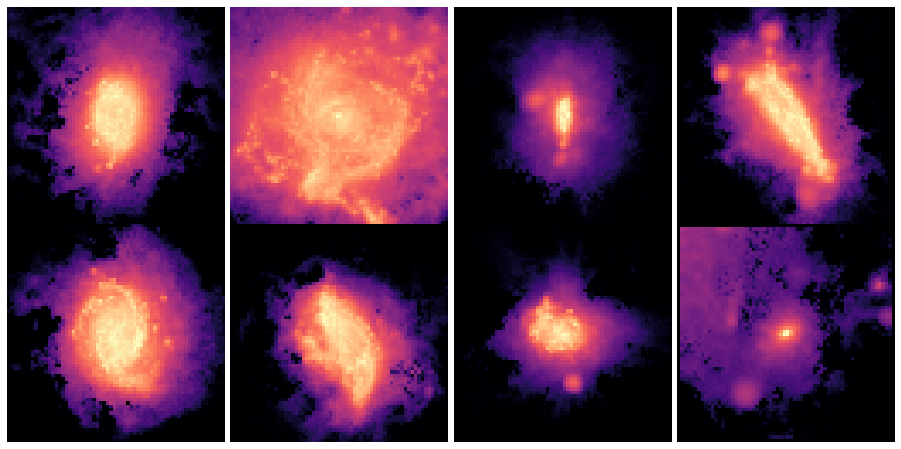

In [14]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for i in range(2):
    for j in range(4):
        k = i * 4 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

# 128

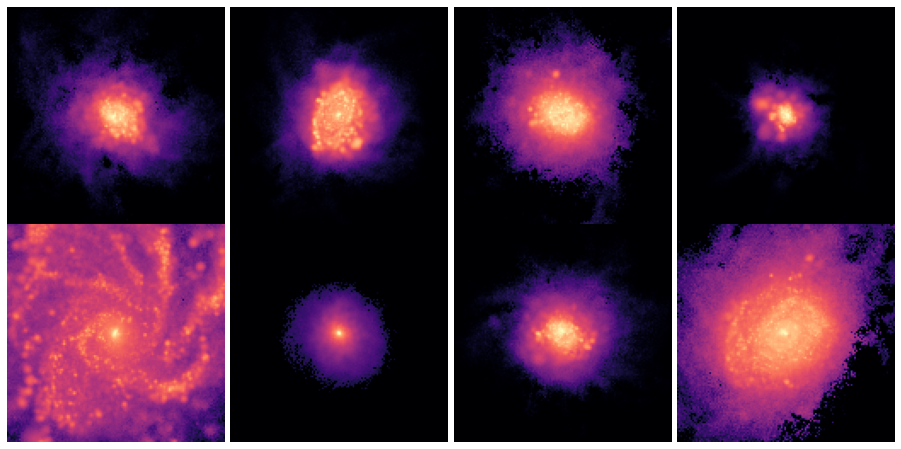

In [28]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for i in range(2):
    for j in range(4):
        k = i * 4 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

# 256

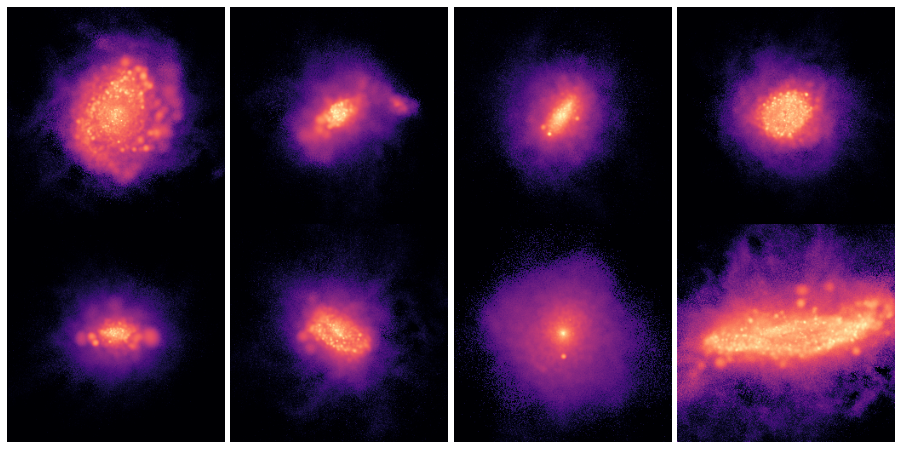

In [10]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for i in range(2):
    for j in range(4):
        k = i * 4 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)